**Representación gráfica de la función de optimización**

In [1]:
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt

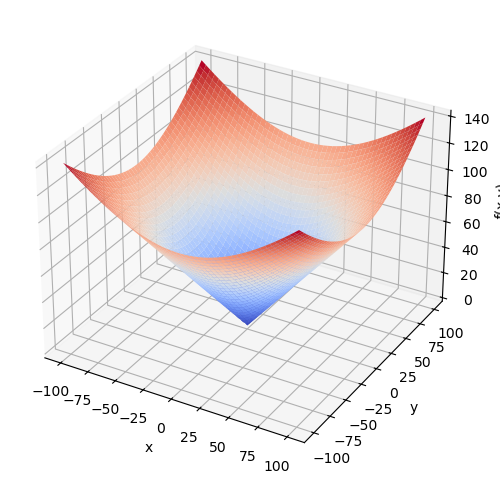

In [2]:
# Definimos la función objetivo
def funcion_prueba(x):
    res = np.sqrt(x[0] ** 2 + x[1] ** 2)
    return res

# Generamos vectores que barran todo el dominio
x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

# Evaluamos todos los valores de las variables
x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_[x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

# Representamos los resultados obtenidos
figure_3d = plt.figure(figsize=(8, 6))
ax = figure_3d.add_subplot(111, projection="3d")

ax.plot_surface(x_ax, y_ax, fx, cmap=cm.coolwarm)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

plt.show()

**Códificación del algoritmo génetico**

In [3]:
!pip install deap

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

In [5]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

In [6]:
creator.create("Individual",list,fitness=creator.FitnessMax)

In [7]:
toolbox = base.Toolbox()

In [8]:
#Generación de genes
toolbox.register("attr_uniform", random.uniform, -100,100)

In [9]:
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform, 2)

In [11]:
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 10)

In [12]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
        res = math.sqrt(x[0]**2+x[1]**2)
        return res,

In [13]:
toolbox.register("evaluate", funcion_objetivo)

In [14]:
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

In [16]:
"""
Representa la evolución del mejor individuo en cada generación
"""
def plot_evolucion(log):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs, where=where_mask, facecolor='g', alpha=0.2)
    
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(["Min", "Max", "Avg"], loc="lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps", dpi=300)

gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	136.566	1.22103	133.156	138.275
15 	6     	136.928	0.4487 	136.779	138.275
16 	5     	136.928	0.4487 	136.779	138.275
17 	6     	137.377	0.732724	136.779	138.275
18 	6     	137.826	0.685401	136.779	138.275
19 	6     	137.951	0.969782	135.042	138.275
20 	4     	138.275	0       	138.275	138.275
Mejor fitness: 138.274563
Mejor individuo [-94.69280

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


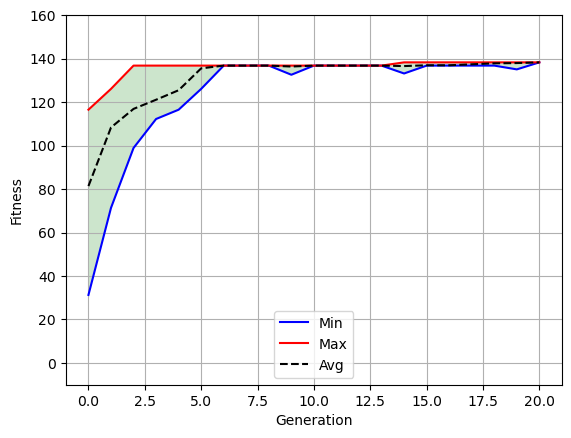

In [17]:
def main():
    random.seed(42) # Semilla del generador de los números pseudoaleatorios
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20 # Probabilidades de cruza, muta y número de generaciones
    pop = toolbox.population() # Generación de la población inicial
    hof = tools.HallOfFame(1) # Almacena al mejor individuo encontrado en todas las generaciones
    stats = tools.Statistics(lambda ind: ind.fitness.values) # Generar las estadísticas de población sobre el fitness
    stats.register("avg", np.mean) # Calcular la media
    stats.register("std", np.std) # Desviación estándar típica
    stats.register("min", np.min) # Valor mínimo absoluto de la generación
    stats.register("max", np.max) # Valor máximo absoluto de la generación
    logbook = tools.Logbook()
    
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    return hof, logbook

if __name__ == "__main__":
    best, log = main()
    print("Mejor fitness: %f" % best[0].fitness.values)
    print("Mejor individuo %s" % best[0])
    plot_evolucion(log)

**Población de 30 y 50 individuos, con 20 generaciones**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


gen	nevals	avg    	std   	min    	max    
0  	30    	77.9162	24.544	26.4289	116.497
1  	15    	98.1576	15.6516	58.7221	123.194
2  	18    	108.641	17.0172	47.071 	131.857
3  	24    	122.041	7.64215	99.9797	134.549
4  	19    	128.584	3.92487	122.005	134.549
5  	11    	132.005	2.13284	125.135	134.549
6  	22    	133.419	1.60997	131.169	136.779
7  	20    	135.251	2.15952	131.169	143.034
8  	17    	136.843	2.32869	133.455	143.034
9  	16    	138.636	2.97413	134.132	143.69 
10 	14    	141.666	2.94994	136.779	146.03 
11 	15    	143.198	1.63885	137.486	146.03 
12 	23    	144.16 	0.958894	143.034	146.157
13 	21    	139.741	26.1601 	-1     	146.219
14 	17    	144.946	1.46991 	139.997	146.219
15 	15    	140.982	26.3831 	-1     	148.703
16 	15    	146.497	0.855167	146.03 	148.703
17 	15    	147.219	1.32682 	144.439	148.703
18 	18    	148.372	0.844397	146.219	148.703
19 	20    	148.618	0.367437	146.713	148.703
20 	20    	148.671	0.173246	147.738	148.703
Mejor fitness: 148.703072
Mejor individuo [-99.

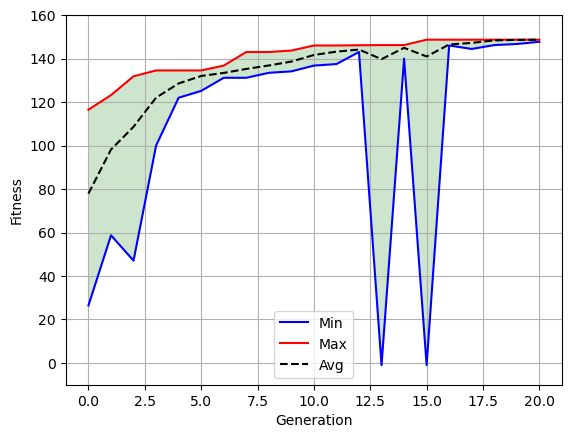

In [19]:
#30 individuos
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 30)
best, log = main()
print("Mejor fitness: %f" % best[0].fitness.values)
print("Mejor individuo %s" % best[0])
plot_evolucion(log)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


gen	nevals	avg    	std    	min    	max    
0  	50    	79.5138	24.5664	26.4289	122.059
1  	28    	97.8301	18.6489	48.4558	130.873
2  	28    	115.187	13.6357	83.2838	140.132
3  	40    	124.553	19.4919	-1     	136.574
4  	27    	133.61 	3.47646	119.014	140.132
5  	37    	135.631	2.05285	130.873	140.132
6  	30    	137.17 	2.366  	132.439	143.284
7  	29    	136.007	19.6627	-1     	143.284
8  	34    	140.478	1.25102	137.767	143.284
9  	30    	141.357	1.52454	139.954	143.84 
10 	28    	142.574	1.38277	138.232	143.84 
11 	30    	143.329	0.150888	143.284	143.84 
12 	27    	143.418	0.237535	143.284	143.84 
13 	32    	143.431	1.36029 	137.306	148.876
14 	29    	144.02 	1.25409 	142.603	148.876
15 	28    	144.638	1.85072 	143.427	148.876
16 	29    	146.376	2.50305 	143.84 	148.876
17 	31    	148.351	1.58161 	142.759	148.876
18 	28    	148.723	0.783624	143.934	148.876
19 	34    	148.876	0       	148.876	148.876
20 	25    	149.039	1.13866 	148.876	157.009
Mejor fitness: 157.009497
Mejor individuo [9

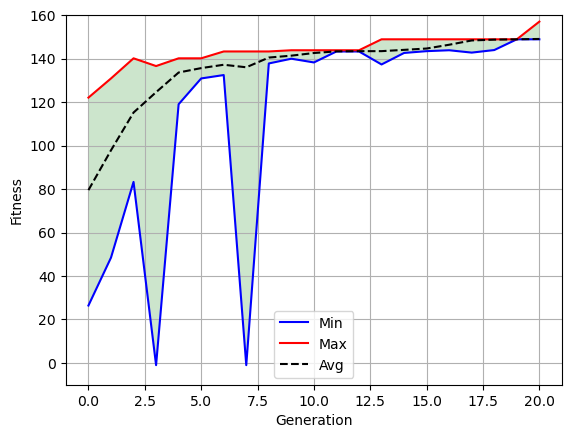

In [22]:
#50 individuos
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 50)
best, log = main()
print("Mejor fitness: %f" % best[0].fitness.values)
print("Mejor individuo %s" % best[0])
plot_evolucion(log)

**Tabla comparativa**

| Parámetro | Prueba 1 (Guía) | Prueba 2 (Manual) | Prueba 3 (Tarea) |
| :--- | :---: | :---: | :---: |
| **Tamaño de Población** | 10 individuos | 20 individuos | 50 individuos |
| **Número de Generaciones** | 20 | 20 | 20 |
| **Mejor Fitness Hallado** | 138.274563 | 148.703072 | 157.009497 |
| **Individuo (x, y)** | [-94.69, -100.76] | [-99.34, -110.64] | [99.47, -121.47] |
| **Generación de Convergencia** | Gen ~10 | Gen ~16 | Gen ~13 |

**Análisis de los resultados finales:**
* **Exploración y Fitness:** El incremento de la población de 10 a 50 individuos permitió obtener un fitness superior. Esto confirma que una mayor población inicial garantiza una diversidad genética que potencia la fuerza de exploración del algoritmo.
* **Calidad de la Solución:** Con 50 individuos, el algoritmo logró encontrar valores más alejados del origen, acercándose a las soluciones óptimas en los bordes del dominio.
* **Estabilidad y Convergencia:** En la gráfica de 50 individuos, la línea de aptitud media (**Avg**) muestra un crecimiento más sólido y sostenido.Aunque aparecen picos de fitness bajo debido a mutaciones o cruces desfavorables, el valor máximo (**Max**) logra estabilizarse en niveles más altos que en las pruebas con menos población.